In [2]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 
import math
from cartopy.util import add_cyclic_point
from sklearn import linear_model as lm
import statsmodels.formula.api as stm
from sklearn.metrics import r2_score
from numpy import genfromtxt
import rioxarray
from sklearn.linear_model import TheilSenRegressor
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
import statsmodels.api as sm



from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import seaborn as sns
#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from rasterio import features
from affine import Affine
import geopandas as gp

plt.rcParams['hatch.linewidth'] = 1.5
plt.rcParams['hatch.color'] = 'k'
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.size'] = "16"
from matplotlib import rcParams
rcParams["mathtext.default"] = "regular"

import warnings
warnings.filterwarnings(action='ignore')

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl1020/lib/python3.8/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


In [3]:
load_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/'

In [89]:
# load panel
df = pd.read_csv(load_dir+'pexq_df_GPCP.csv') 

# for CPC panel, need basin ids:
#basins = pd.read_csv(load_dir+'basin_id_df.csv')

# add basins to df:
#df_cpc['basin_id'] = basins.basin_id

In [90]:
# define function to group the lon/lat dims into coarser reslution bins:
def coarsen(df, res):
    df = df.copy()
    df['lat_bin'] = np.floor(df['lat'] / res) * res
    df['lon_bin'] = np.floor(df['lon'] / res) * res
    return df

#define function to select modal basin id per bin
def mode_or_nan(x):
    m = x.mode()
    return m.iloc[0] if len(m) > 0 else np.nan

# declare dict containing all variables to agg and the operation (spatial mean for all variables, but not for basin...)
agg_dict = {
    'LWE': 'mean',
    'P_GPCP': 'mean',
    'T': 'mean',
    'Gp_GPCP':'mean',
    'Pmean_GPCP':'mean',
    'basin_id': mode_or_nan
}


In [91]:
#reslutions to test
res = [1,2,3]

#loop over resolutions
for r in res:
    
    #coarsen lat/lon dims
    df_1deg = coarsen(df, float(r))
    
    # feed agg dict to .agg after grouping by lat and lon bins
    df_1deg_agg = (
        df_1deg
        .groupby(['water_year', 'lat_bin', 'lon_bin'], as_index=False)
        .agg(agg_dict)
    )

    #put back old names:
    df_1deg_agg = df_1deg_agg.rename(columns={'lat_bin':'lat','lon_bin':'lon'})

    # add gridindex for fixed effects:
    df_1deg_agg['gridindex'] = df_1deg_agg['lat'].astype(str) + '_' + df_1deg_agg['lon'].astype(str)

    df_1deg_agg.to_csv(load_dir+'pexq_df_GPCP_' + str(r) + '_deg.csv')

In [40]:
df_1deg_agg

,water_year,lat,lon,LWE,P,T,Gp_anoms,Pmean,basin_id,gridindex
0,2002,-55.0,287.0,-2.587649,-321.779330,0.061895,-0.008214,385.397600,NaN,-55.0_287.0
1,2002,-55.0,288.0,-2.680072,-277.088929,-0.034078,-0.019020,376.640010,NaN,-55.0_288.0
2,2002,-55.0,289.0,-2.865715,-277.493262,-0.142531,-0.026908,416.366820,NaN,-55.0_289.0
3,2002,-55.0,290.0,-3.077952,-270.040149,-0.256765,-0.017898,439.100237,NaN,-55.0_290.0
4,2002,-55.0,291.0,-2.641071,-254.005458,-0.327608,-0.002146,437.938825,3403.0,-55.0_291.0
...,...,...,...,...,...,...,...,...,...,...
292583,2022,69.0,332.0,6.906879,64.923147,-4.661569,-0.166685,417.064835,NaN,69.0_332.0
292584,2022,69.0,333.0,2.932827,33.604222,-4.212120,-0.167544,425.381400,NaN,69.0_333.0
292585,2022,69.0,334.0,-2.848090,27.385456,-3.944965,-0.171622,436.013335,NaN,69.0_334.0
292586,2022,69.0,335.0,-2.507546,29.774602,-3.973574,-0.178477,447.375240,NaN,69.0_335.0


# plot

In [6]:
# function to compute 95% estimation CI of fit
def intSE(y,se_Gp,se_GpP,cov,scale=1,n_se=2):
    variance = se_Gp**2 + (x**2) * se_GpP**2 + 2*x * cov
    se = np.sqrt(variance)
    effecthi = y+scale*n_se*se
    effectlo = y-scale*n_se*se
    return effectlo,effecthi


In [7]:
# Set scale and prange
scale = 1 
bmin = 0
bmax = 3600
freq = 100
x = np.arange(bmin,bmax,freq)



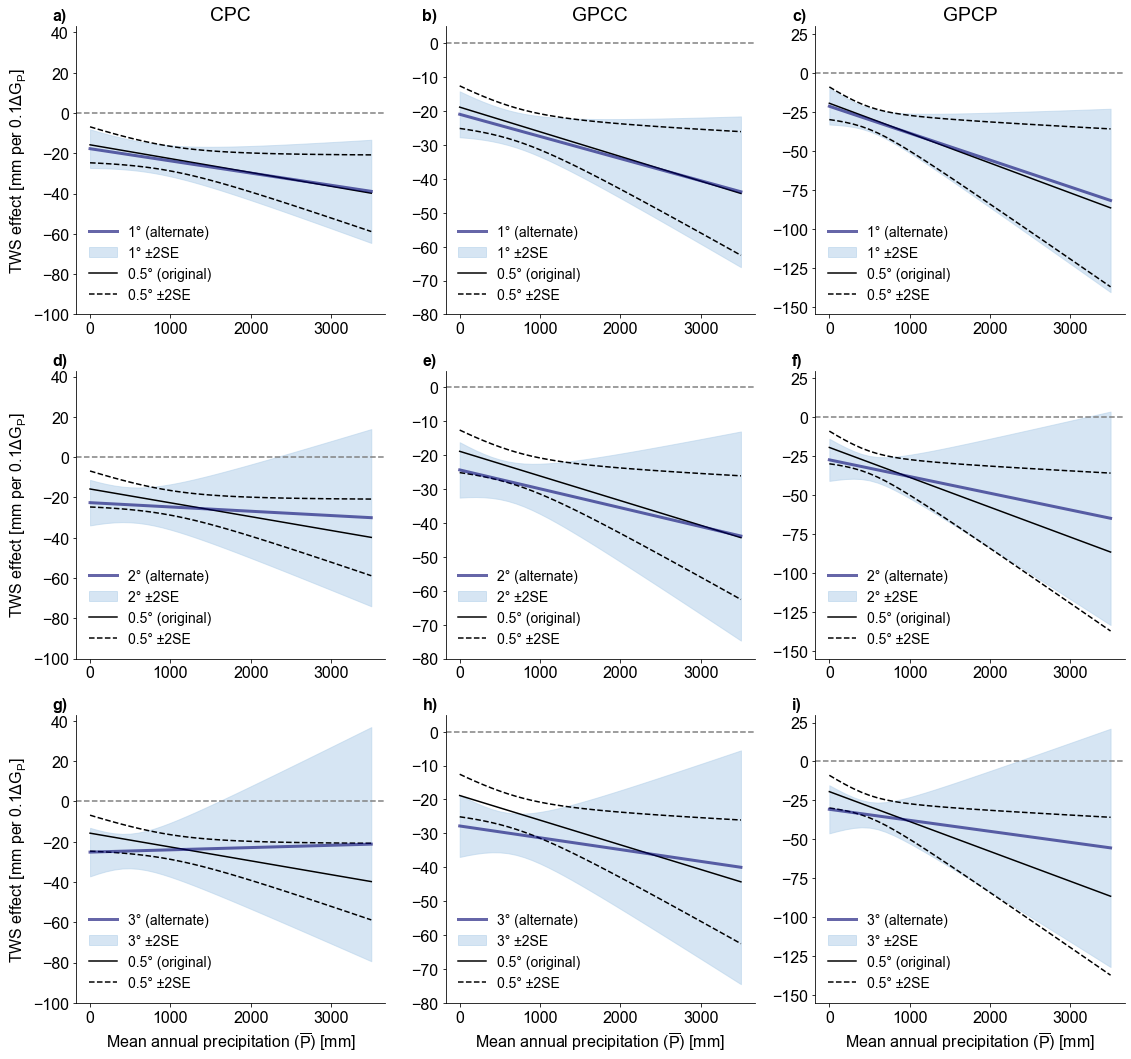

In [127]:
fsizel = 14
lets = 'abcd'

fig = plt.figure(figsize=(16,15))

axs = []
gs = GridSpec(3, 3)

axs.append(fig.add_subplot(gs[0,0]))
axs.append(fig.add_subplot(gs[1,0]))
axs.append(fig.add_subplot(gs[2,0]))
axs.append(fig.add_subplot(gs[0,1]))
axs.append(fig.add_subplot(gs[1,1]))
axs.append(fig.add_subplot(gs[2,1]))
axs.append(fig.add_subplot(gs[0,2]))
axs.append(fig.add_subplot(gs[1,2]))
axs.append(fig.add_subplot(gs[2,2]))

ylims = [[-100,43],[-80,5],[-155,30]]

res = [1,2,3]
dataset = ['CPC','GPCC','GPCP']

for i,ax in enumerate(axs):
    
    #prep conditional tws effect:
    cpc_results_1deg = pd.read_csv(load_dir+'reg_results/' + dataset[i//3] +'_' + str(i%3+1) + 'deg.csv')
    y1deg_cpc = scale*cpc_results_1deg.coef_Gp[0]+scale*cpc_results_1deg.coef_GpP[0]*x
    effectlo1deg_cpc, effecthi1deg_cpc = intSE(y1deg_cpc,cpc_results_1deg.se_Gp[0],cpc_results_1deg.se_GpP[0],cpc_results_1deg.vcov[0])
    
    #prep original resolution tws effect:
    cpc_results = pd.read_csv(load_dir+'reg_results/' + dataset[i//3] + '_regression_results.csv')
    y_cpc = scale*cpc_results.coef_Gp[0]+scale*cpc_results.coef_GpP[0]*x
    effectlo_cpc, effecthi_cpc = intSE(y_cpc,cpc_results.se_Gp[0],cpc_results.se_GpP[0],cpc_results.vcov[0])

    color='cadetblue'

    l0=ax.plot(x,y_cpc,'k-')
    l1=ax.plot(x,effectlo_cpc,'k--')
    ax.plot(x,effecthi_cpc,'k--')

    l2=ax.plot(x,y1deg_cpc,color='#01016f',linewidth=3,alpha=0.6)
    f0=ax.fill_between(x,effectlo1deg_cpc,effecthi1deg_cpc,color='#aecde8',alpha=0.5)
    ax.axhline(0,linestyle='--',color='grey')
    
    if i in [0,1,2]:
        ax.set_ylabel('TWS effect [mm per $0.1 \Delta G_P$]')
    
    
    ax.legend([l2[0],f0,l0[0],l1[0]],[str(i%3+1)+'° (alternate)',
                                      str(i%3+1)+'° ±2SE',
                                      '0.5° (original)',
                                      '0.5° ±2SE'],
              fontsize=fsizel,frameon=False)

    if i in [0,3,6]:
        ax.set_title(dataset[i//3])

    ax.set_ylim(ylims[i//3])
    
    if i in [2,5,8]:
        ax.set_xlabel('Mean annual precipitation ('+r'$\overline{P}$) [mm]')

# axis adjustments
lets = 'adgbehcfi'
for i,ax in enumerate(axs):
    ax.spines[['right', 'top']].set_visible(False)
    ax.text(-0.075,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    

plt.tight_layout()


### Plot conley SEs

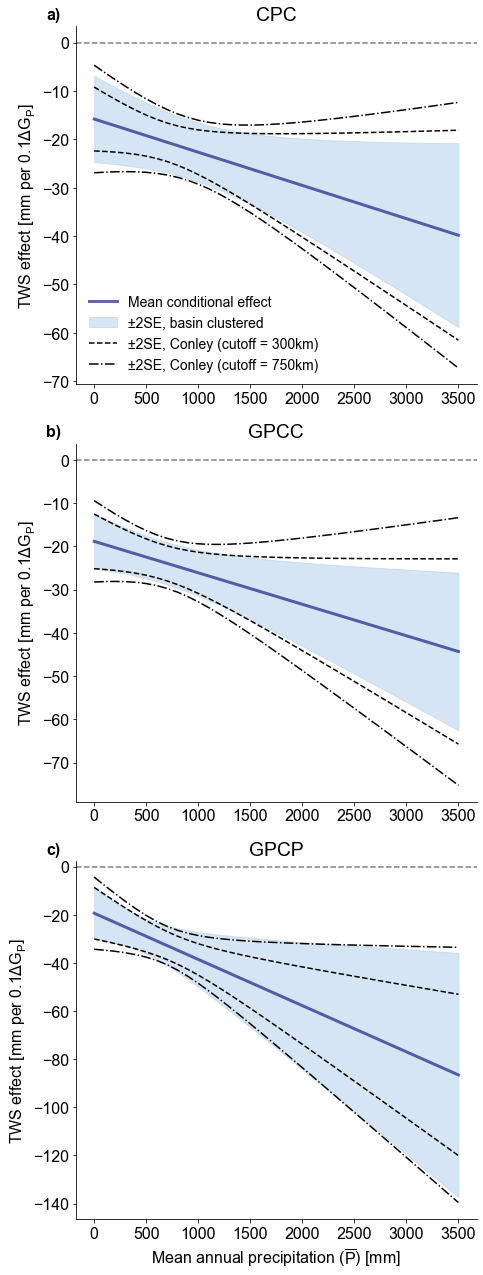

In [125]:
fsizel = 14
lets = 'abcd'

fig = plt.figure(figsize=(7,18))

axs = []
gs = GridSpec(3, 1)

axs.append(fig.add_subplot(gs[0,0]))
axs.append(fig.add_subplot(gs[1,0]))
axs.append(fig.add_subplot(gs[2,0]))

dataset = ['CPC','GPCC','GPCP']

#conley ses
ses_300 = [[3.3,0.0038,-0.01],[3.16,0.0037,-0.009],[5.35,0.006,-0.027]]
ses_750 = [[5.56,0.0051,-0.023],[4.7,0.0054,-0.02],[7.49,0.0093,-0.059]]

for i,ax in enumerate(axs):
    
    cpc_results = pd.read_csv(load_dir+'reg_results/' + dataset[i] + '_regression_results.csv')
    y_cpc = scale*cpc_results.coef_Gp[0]+scale*cpc_results.coef_GpP[0]*x
    effectlo_cpc, effecthi_cpc = intSE(y_cpc,cpc_results.se_Gp[0],cpc_results.se_GpP[0],cpc_results.vcov[0])
    lo_c300_cpc,hi_c300_cpc = intSE(y_cpc,ses_300[i][0],ses_300[i][1],ses_300[i][2])
    lo_c200_cpc,hi_c200_cpc = intSE(y_cpc,ses_750[i][0],ses_750[i][1],ses_750[i][2])

    l1=ax.plot(x,lo_c300_cpc,'k--')
    ax.plot(x,hi_c300_cpc,'k--')

    l2=ax.plot(x,lo_c200_cpc,'k-.')
    ax.plot(x,hi_c200_cpc,'k-.')

    l3=ax.plot(x,y_cpc,color='#01016f',linewidth=3,alpha=0.6)
    f0=ax.fill_between(x,effectlo_cpc,effecthi_cpc,color='#aecde8',alpha=0.5)
    ax.axhline(0,linestyle='--',color='grey')
    ax.set_ylabel('TWS effect [mm per $0.1 \Delta G_P$]')
    
    if i == 0:
        ax.legend([l3[0],f0,l1[0],l2[0]],['Mean conditional effect','±2SE, basin clustered','±2SE, Conley (cutoff = 300km)','±2SE, Conley (cutoff = 750km)'],
             fontsize=fsizel,frameon=False)
        
    if i == 2:
        ax.set_xlabel('Mean annual precipitation ('+r'$\overline{P}$) [mm]')
   

    ax.set_title(dataset[i])

lets = 'abcdefghi'
for i,ax in enumerate(axs):
    ax.spines[['right', 'top']].set_visible(False)
    ax.text(-0.075,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    
plt.tight_layout()

0
1
2


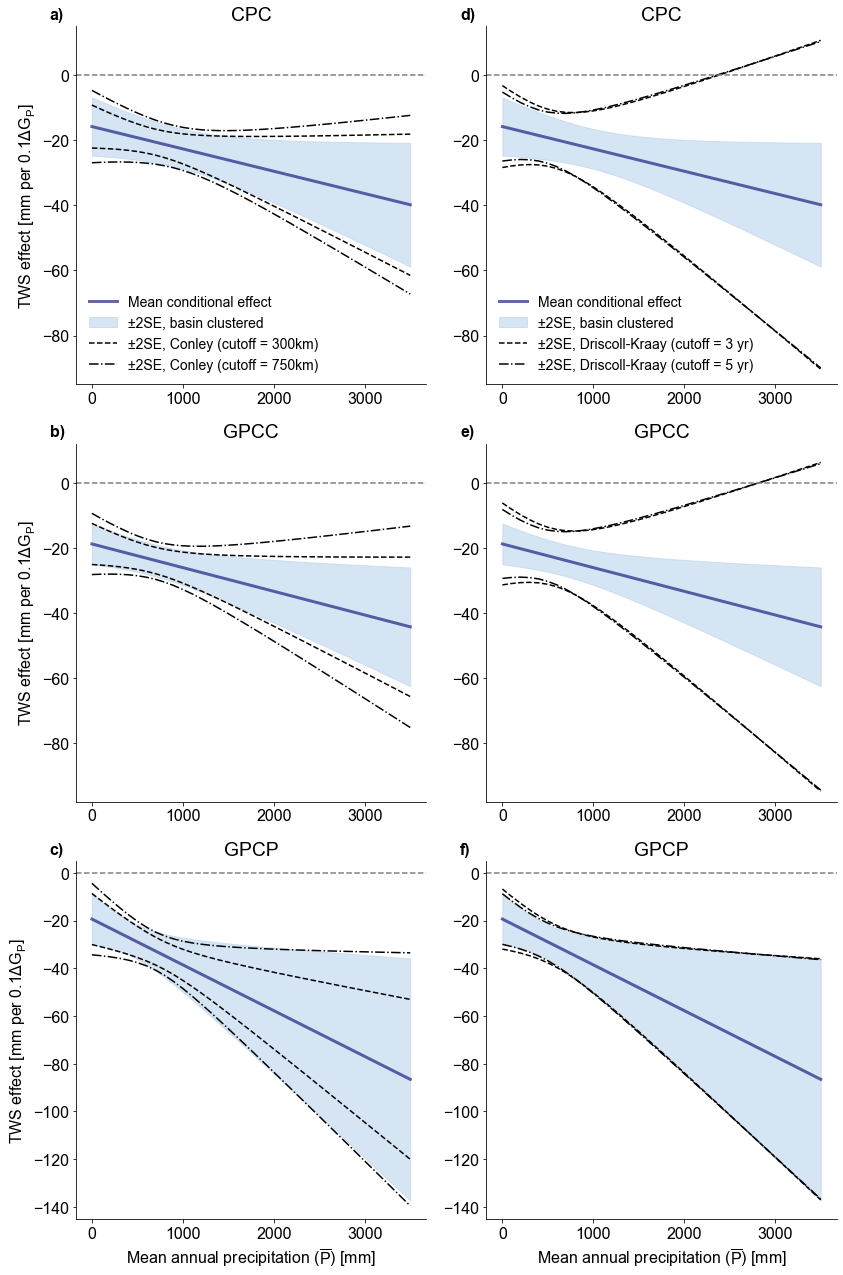

In [36]:
#temporal Driscoll-Kraay SEs
fsizel = 14
lets = 'abcd'
scale=1

fig = plt.figure(figsize=(12,18))

axs = []
gs = GridSpec(3, 2)

axs.append(fig.add_subplot(gs[0,0]))
axs.append(fig.add_subplot(gs[1,0]))
axs.append(fig.add_subplot(gs[2,0]))
axs.append(fig.add_subplot(gs[0,1]))
axs.append(fig.add_subplot(gs[1,1]))
axs.append(fig.add_subplot(gs[2,1]))

dataset = ['CPC','GPCC','GPCP']
ylims = [[-95,15],[-98,12],[-145,5]]
#conley ses
ses_300 = [[3.3,0.0038,-0.01],[3.16,0.0037,-0.009],[5.35,0.006,-0.027]]
ses_750 = [[5.56,0.0051,-0.023],[4.7,0.0054,-0.02],[7.49,0.0093,-0.059]]

for i,ax in enumerate(axs[:3]):
    
    cpc_results = pd.read_csv(load_dir+'reg_results/' + dataset[i] + '_regression_results.csv')
    y_cpc = scale*cpc_results.coef_Gp[0]+scale*cpc_results.coef_GpP[0]*x
    effectlo_cpc, effecthi_cpc = intSE(y_cpc,cpc_results.se_Gp[0],cpc_results.se_GpP[0],cpc_results.vcov[0])
    lo_c300_cpc,hi_c300_cpc = intSE(y_cpc,ses_300[i][0],ses_300[i][1],ses_300[i][2])
    lo_c200_cpc,hi_c200_cpc = intSE(y_cpc,ses_750[i][0],ses_750[i][1],ses_750[i][2])

    l1=ax.plot(x,lo_c300_cpc,'k--')
    ax.plot(x,hi_c300_cpc,'k--')

    l2=ax.plot(x,lo_c200_cpc,'k-.')
    ax.plot(x,hi_c200_cpc,'k-.')

    l3=ax.plot(x,y_cpc,color='#01016f',linewidth=3,alpha=0.6)
    f0=ax.fill_between(x,effectlo_cpc,effecthi_cpc,color='#aecde8',alpha=0.5)
    ax.axhline(0,linestyle='--',color='grey')
    ax.set_ylabel('TWS effect [mm per $0.1 \Delta G_P$]')
    
    if i == 0:
        ax.legend([l3[0],f0,l1[0],l2[0]],['Mean conditional effect','±2SE, basin clustered','±2SE, Conley (cutoff = 300km)','±2SE, Conley (cutoff = 750km)'],
             fontsize=fsizel,frameon=False)
        
    if i == 2:
        ax.set_xlabel('Mean annual precipitation ('+r'$\overline{P}$) [mm]')
   
    ax.set_ylim(ylims[i])
    ax.set_title(dataset[i])

######

#Driscoll-Kraay ses
ses_300 = [[1.748,0.007,-0.006],[2.1,0.0048,-0.0044],[6.29,0.0084,-0.038]]
ses_750 = [[1.6,0.0073,-0.006],[1.96,0.0047,-0.005],[5.3,0.0081,-0.029]]

for j,ax in enumerate(axs[i+1:]):
    print(j)
    cpc_results = pd.read_csv(load_dir+'reg_results/' + dataset[j] + '_regression_results.csv')
    y_cpc = scale*cpc_results.coef_Gp[0]+scale*cpc_results.coef_GpP[0]*x
    effectlo_cpc, effecthi_cpc = intSE(y_cpc,cpc_results.se_Gp[0],cpc_results.se_GpP[0],cpc_results.vcov[0])
    lo_c300_cpc,hi_c300_cpc = intSE(y_cpc,ses_300[i][0],ses_300[i][1],ses_300[i][2])
    lo_c200_cpc,hi_c200_cpc = intSE(y_cpc,ses_750[i][0],ses_750[i][1],ses_750[i][2])

    l1=ax.plot(x,lo_c300_cpc,'k--')
    ax.plot(x,hi_c300_cpc,'k--')

    l2=ax.plot(x,lo_c200_cpc,'k-.')
    ax.plot(x,hi_c200_cpc,'k-.')

    l3=ax.plot(x,y_cpc,color='#01016f',linewidth=3,alpha=0.6)
    f0=ax.fill_between(x,effectlo_cpc,effecthi_cpc,color='#aecde8',alpha=0.5)
    ax.axhline(0,linestyle='--',color='grey')
    #ax.set_ylabel('TWS effect [mm per $0.1 \Delta G_P$]')
    
    if j == 0:
        ax.legend([l3[0],f0,l1[0],l2[0]],['Mean conditional effect','±2SE, basin clustered','±2SE, Driscoll-Kraay (cutoff = 3 yr)','±2SE, Driscoll-Kraay (cutoff = 5 yr)'],
             fontsize=fsizel,frameon=False)
        
    if j == 2:
        ax.set_xlabel('Mean annual precipitation ('+r'$\overline{P}$) [mm]')
   

    ax.set_title(dataset[j])
    ax.set_ylim(ylims[j])
lets = 'abcdefghi'
for i,ax in enumerate(axs):
    ax.spines[['right', 'top']].set_visible(False)
    ax.text(-0.075,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    
plt.tight_layout()

In [ ]:
### find mean basin area

In [18]:
from shapely.geometry import Polygon
import numpy as np

def max_distance(polygon):
    # Take convex hull to simplify shape
    hull = polygon.convex_hull
    
    # Only the exterior coordinates, as Nx2 array
    coords = np.array(hull.exterior.coords.xy).T  # coords.xy gives (2, N), transpose to (N,2)
    
    # Compute all pairwise distances
    diff = coords[:, None, :] - coords[None, :, :]  # shape (N, N, 2)
    dists = np.sqrt((diff ** 2).sum(-1))  # shape (N, N)
    
    return dists.max()


grdc_basins['length_max_dist'] = grdc_basins.geometry.apply(max_distance)

grdc_basins.length_max_dist.min()/1000

In [126]:
8.47e-4*3600


3.0492